## Preguntas de analisis

In [29]:
import pandas as pd

# Definir la ruta base donde están los archivos
ruta = r"C:\Users\lucfe\Dropbox\UNIVERSIDAD\APRENDIZAJE AUTOMATICO\TP00\aprendizaje_automatico_2025\data\raw"

# Cargar los CSV
recorridos = pd.read_csv(rf"{ruta}\badata_ecobici_recorridos_realizados_2024.csv")
usuarios = pd.read_excel(rf"{ruta}\usuarios_ecobici_2024.xlsx")

# Ver las primeras filas para verificar
print("Recorridos:")
display(recorridos.head())

print("Usuarios:")
display(usuarios.head())

Recorridos:


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


Usuarios:


,ID_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta,Customer.Has.Dni..Yes...No.
0,1224742,FEMALE,24.0,2024-10-08,12:34:05,No
1,1224990,MALE,18.0,2024-10-08,18:58:27,No
2,1225021,MALE,30.0,2024-10-08,19:55:22,No
3,1224773,OTHER,23.0,2024-10-08,13:25:01,No
4,1225009,MALE,21.0,2024-10-08,19:24:09,No


# 1. ¿Cuál fue la cantidad total de viajes realizados por usuarios de entre 25 y 35 años durante los tres meses seleccionados?

In [25]:

print(usuarios.columns)
print(recorridos.columns)


Index(['ID_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta',
       'hora_alta', 'Customer.Has.Dni..Yes...No.'],
      dtype='object')
Index(['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
       'id_estacion_origen', 'nombre_estacion_origen',
       'direccion_estacion_origen', 'long_estacion_origen',
       'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino',
       'nombre_estacion_destino', 'direccion_estacion_destino',
       'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
       'modelo_bicicleta', 'genero'],
      dtype='object')


In [ ]:
# Normalizar nombres de columnas para merge
recorridos.rename(columns={"ID_usuario": "id_usuario"}, inplace=True)  # Porque hay uno q es con mayuscula y otro minuscula
usuarios.rename(columns={"ID_usuario": "id_usuario"}, inplace=True)


# Función para intentar convertir columnas con fechas a datetime
def convertir_fechas(df):
    for col in df.columns:
        if "fecha" in col.lower() or "date" in col.lower():
            try:
                df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
                print(f"Columna convertida a datetime: {col}")
            except Exception as e:
                print(f"No se pudo convertir {col}: {e}")
    return df

# Aplicar a los dos datasets
recorridos = convertir_fechas(recorridos)
usuarios = convertir_fechas(usuarios)

# Filtrar por fechas (julio a septiembre 2024)
col_fecha = "fecha_origen_recorrido"
inicio = pd.Timestamp(2024, 7, 1)
fin_exclusivo = pd.Timestamp(2024, 10, 1)  # < 1/10/2024 equivale a <= 30/09/2024 23:59:59

mask = (recorridos[col_fecha] >= inicio) & (recorridos[col_fecha] < fin_exclusivo)
viajes_jul_sep = recorridos.loc[mask].copy()
print(f"Cantidad de viajes entre {inicio.date()} y 2024-09-30 (inclusive): {len(viajes_jul_sep)}")

# Merge con usuarios para obtener edad
df_completo = viajes_jul_sep.merge(
    usuarios[["id_usuario", "edad_usuario"]],  # columnas necesarias
    on="id_usuario",
    how="left"
)

# Filtrar por edades 25 y 35
edades_interes = [25, 35]
mask_edad = df_completo["edad_usuario"].isin(edades_interes)
viajes_filtrados = df_completo.loc[mask_edad].copy()

# Cantidad total de viajes para esas edades
cantidad_viajes = viajes_filtrados.shape[0]
print(f"Cantidad de viajes entre {inicio.date()} y 2024-09-30 para edades 25 y 35: {cantidad_viajes}")

# Desglose por mes
viajes_filtrados["mes"] = viajes_filtrados[col_fecha].dt.to_period("M")
print("\nViajes por mes para esas edades:")
print(viajes_filtrados["mes"].value_counts().sort_index())


Columna convertida a datetime: fecha_origen_recorrido
Columna convertida a datetime: fecha_destino_recorrido
Columna convertida a datetime: fecha_alta
Cantidad de viajes entre 2024-07-01 y 2024-09-30 (inclusive): 831984
Cantidad de viajes entre 2024-07-01 y 2024-09-30 para edades 25 y 35: 15085

Viajes por mes para esas edades:
mes
2024-07    3845
2024-08    4173
2024-09    7067
Freq: M, Name: count, dtype: int64


# 2. ¿Cuáles fueron las 5 estaciones de inicio con mayor cantidad de viajes en esos tres meses?

In [34]:
# Contar viajes por estación de origen
estaciones_top5 = viajes_filtrados["nombre_estacion_origen"].value_counts().head(5)

print("Top 5 estaciones de inicio con mayor cantidad de viajes:")
print(estaciones_top5)


Top 5 estaciones de inicio con mayor cantidad de viajes:
nombre_estacion_origen
014 - Pacifico                     285
005 - Plaza Italia                 269
368 - PLAZA DE LA SHOÁ             253
294 - PLAZOLETA RÍO DE LA PLATA    188
001 - FACULTAD DE DERECHO          185
Name: count, dtype: int64


# 3. Entre los usuarios frecuentes (más de 15 viajes en el período), ¿cuál es la distribución por género?

In [35]:
# Contar viajes por usuario
viajes_por_usuario = viajes_filtrados.groupby("id_usuario").size().reset_index(name="cantidad_viajes")

# Filtrar usuarios frecuentes (>15 viajes)
usuarios_frecuentes = viajes_por_usuario[viajes_por_usuario["cantidad_viajes"] > 15]

# Merge para traer género
usuarios_frecuentes = usuarios_frecuentes.merge(
    usuarios[["id_usuario", "genero_usuario"]],
    on="id_usuario",
    how="left"
)

# Distribución por género
distribucion_genero = usuarios_frecuentes["genero_usuario"].value_counts()

print("Distribución por género de usuarios frecuentes (>15 viajes):")
print(distribucion_genero)


Distribución por género de usuarios frecuentes (>15 viajes):
genero_usuario
MALE      145
FEMALE     74
OTHER       3
Name: count, dtype: int64


## Visualizacion

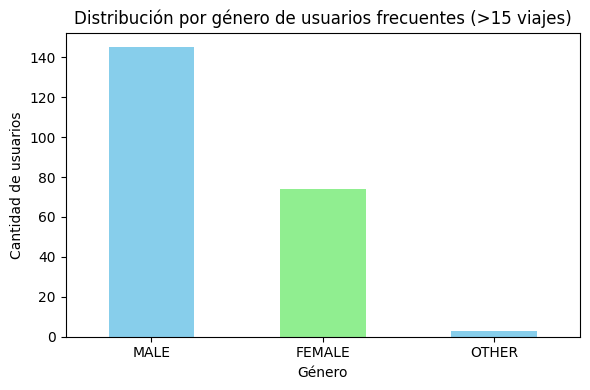

In [41]:
import matplotlib.pyplot as plt
import os

# Asegurarnos de que la carpeta existe
os.makedirs("../reports/figures", exist_ok=True)

# Gráfico de barras de distribución por género
plt.figure(figsize=(6,4))
distribucion_genero.plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("Distribución por género de usuarios frecuentes (>15 viajes)")
plt.xlabel("Género")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()

# Guardar la figura
plt.savefig("../reports/figures/viajes_por_genero.png", dpi=300)
plt.show()
